# Analisis de trafico y de la base de datos del portal Joomla

**Parcial 2 practico - Comunicaciones - Ingenieria Mecatronica**
Universidad Militar Nueva Granada

Este cuaderno viene **precargado** en el contenedor `jupyter` mediante un
*bind-mount* (`./jupyter/notebooks -> /home/jovyan/work`) y se ejecuta de
principio a fin sin instalar nada adicional.

Lo que hace, en orden:

| Seccion | Contenido | Capa OSI que evidencia |
|---|---|---|
| 1 | Resolucion DNS interna y sondeo de puertos TCP de los 5 servicios | Capas 3 y 4 |
| 2 | Generacion de trafico HTTP contra el proxy inverso | Capa 7 |
| 3 | Consulta al motor PostgreSQL y a las tablas creadas por Joomla | Capa 7 (protocolo de PostgreSQL) |
| 4 | Analisis del access log del edge a traves de vistas SQL + graficas | Capa 7 |
| 5 | Procesado directo del archivo de log con pandas | Capa 7 |
| 6 | Estadisticas internas del motor relacional | Capa 4 / Capa 7 |

> **Sugerencia:** menu *Run > Run All Cells*. La seccion 2 genera el trafico que
> luego analizan las secciones 4 y 5, por lo que conviene respetar el orden.

## 0. Configuracion del entorno

Los parametros de conexion llegan como variables de entorno definidas en
`docker-compose.yml`; el cuaderno no contiene credenciales escritas a mano.

In [14]:
import os
import json
import socket
from datetime import datetime

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text, URL

%matplotlib inline

# --- Parametros tomados del entorno del contenedor --------------------------
PG_HOST = os.getenv("POSTGRES_HOST", "database")
PG_PORT = int(os.getenv("POSTGRES_PORT", "5432"))
PG_DB   = os.getenv("POSTGRES_DB", "joomladb")
PG_USER = os.getenv("POSTGRES_USER", "joomla")
PG_PASS = os.getenv("POSTGRES_PASSWORD", "Comm2026_Postgres")
EDGE_URL = os.getenv("EDGE_URL", "http://nginx")

# Access logs montados en solo lectura desde los volumenes compartidos
LOG_EDGE   = "/home/jovyan/logs/edge/access.json.log"
LOG_JOOMLA = "/home/jovyan/logs/joomla/joomla_access.json.log"

# URL.create escapa correctamente cualquier caracter especial de la clave
DB_URL = URL.create(
    "postgresql+psycopg2",
    username=PG_USER, password=PG_PASS,
    host=PG_HOST, port=PG_PORT, database=PG_DB,
)
engine = create_engine(DB_URL, pool_pre_ping=True)

# --- Estilo unico para todas las graficas del cuaderno ----------------------
SUPERFICIE = "#fcfcfb"
TINTA      = "#0b0b0b"
TINTA_SUAVE = "#52514e"
REJILLA    = "#e1e0d9"

# Color por servicio: asignacion fija, nunca ciclada
COLOR_SERVICIO = {
    "joomla":  "#2a78d6",   # azul
    "jupyter": "#eb6834",   # naranja
    "grafana": "#1baf7a",   # aqua
    "edge":    "#898781",   # gris: sondas de salud, no es trafico de usuario
    "otros":   "#4a3aa7",   # violeta
}
# Color por clase de codigo HTTP: paleta de estado (reservada)
COLOR_STATUS = {
    "2xx": "#0ca30c",   # exito
    "3xx": "#2a78d6",   # redireccion (informativo)
    "4xx": "#fab219",   # error de cliente
    "5xx": "#d03b3b",   # error de servidor
}

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE,
    "axes.facecolor":   SUPERFICIE,
    "axes.edgecolor":   "#c3c2b7",
    "axes.labelcolor":  TINTA_SUAVE,
    "axes.titlesize":   12,
    "axes.titleweight": "bold",
    "axes.titlecolor":  TINTA,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "text.color":       TINTA,
    "xtick.color":      "#898781",
    "ytick.color":      "#898781",
    "grid.color":       REJILLA,
    "grid.linewidth":   0.8,
    "font.size":        10,
    "figure.dpi":       110,
    "legend.frameon":   False,
})

print("pandas    ", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("destino BD", f"{PG_USER}@{PG_HOST}:{PG_PORT}/{PG_DB}")
print("edge HTTP ", EDGE_URL)

pandas     2.2.3
matplotlib 3.9.2
destino BD joomla@database:5432/joomladb
edge HTTP  http://nginx


## 1. Capas 3 y 4: DNS interno de Docker y puertos TCP

Docker publica un servidor DNS embebido en `127.0.0.11` dentro de cada
contenedor. Ese resolvedor solo conoce los nombres de los contenedores que
comparten al menos una red con quien pregunta, de modo que la propia resolucion
de nombres es la primera frontera de aislamiento.

Este contenedor pertenece a `frontend_net` **y** a `backend_net`, asi que deberia
resolver los cinco servicios. `nginx`, en cambio, solo esta en `frontend_net` y
por eso no puede siquiera resolver el nombre `database`.

In [15]:
print("----- /etc/resolv.conf -----")
print(open("/etc/resolv.conf").read().strip())
print("\n----- /etc/hosts (interfaces de este contenedor) -----")
print(open("/etc/hosts").read().strip())

----- /etc/resolv.conf -----
# Generated by Docker Engine.
# This file can be edited; Docker Engine will not make further changes once it
# has been modified.

nameserver 127.0.0.11
options ndots:0

# Based on host file: '/etc/resolv.conf' (internal resolver)
# ExtServers: [host(192.168.65.7)]
# Overrides: []
# Option ndots from: internal

----- /etc/hosts (interfaces de este contenedor) -----
127.0.0.1	localhost
::1	localhost ip6-localhost ip6-loopback
fe00::	ip6-localnet
ff00::	ip6-mcastprefix
ff02::1	ip6-allnodes
ff02::2	ip6-allrouters
172.28.20.4	jupyter
172.28.10.3	jupyter


In [16]:
SERVICIOS = [
    ("nginx",    80,   "Edge router / proxy inverso"),
    ("joomla",   80,   "CMS (Apache + PHP)"),
    ("database", 5432, "PostgreSQL 16"),
    ("grafana",  3000, "Paneles de monitoreo"),
    ("jupyter",  8888, "Este mismo contenedor"),
]

filas = []
for nombre, puerto, rol in SERVICIOS:
    try:
        ip = socket.gethostbyname(nombre)
    except socket.gaierror:
        ip, estado = None, "nombre no resuelto"
    if ip:
        s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        s.settimeout(3)
        estado = "abierto (SYN/ACK)" if s.connect_ex((ip, puerto)) == 0 else "sin respuesta"
        s.close()
    filas.append({"servicio": nombre, "rol": rol, "ip": ip,
                  "puerto_tcp": puerto, "estado": estado})

conectividad = pd.DataFrame(filas)
display(conectividad)

print("\nSubred 172.28.10.0/24 = frontend_net   |   172.28.20.0/24 = backend_net")

,servicio,rol,ip,puerto_tcp,estado
0,nginx,Edge router / proxy inverso,172.28.10.5,80,abierto (SYN/ACK)
1,joomla,CMS (Apache + PHP),172.28.10.4,80,abierto (SYN/ACK)
2,database,PostgreSQL 16,172.28.20.2,5432,abierto (SYN/ACK)
3,grafana,Paneles de monitoreo,172.28.10.2,3000,abierto (SYN/ACK)
4,jupyter,Este mismo contenedor,172.28.20.4,8888,abierto (SYN/ACK)



Subred 172.28.10.0/24 = frontend_net   |   172.28.20.0/24 = backend_net


## 2. Capa 7: generacion de trafico HTTP a traves del proxy inverso

Se lanzan peticiones contra `http://nginx` (el mismo punto de entrada que usa el
navegador en `http://localhost`). Cada peticion deja una linea JSON en el access
log del edge y, cuando el destino es el portal, tambien en el log de Apache.

Estas lineas son exactamente las que alimentan los paneles de Grafana, asi que
al ejecutar esta celda los paneles se pueblan.

In [17]:
import requests

RUTAS = [
    "/",                                   # portada de Joomla
    "/index.php",                          # front controller del CMS
    "/index.php?option=com_users&view=login",
    "/administrator/",                     # backend del CMS
    "/templates/cassiopeia/images/logo.svg",
    "/ruta-inexistente",                   # provoca un 404 para ver clases 4xx
    "/healthz",                            # sonda del propio edge
    "/grafana/api/health",                 # enrutado hacia Grafana
    "/jupyter/api",                        # enrutado hacia Jupyter
]

resultados = []
for vuelta in range(3):
    for ruta in RUTAS:
        try:
            r = requests.get(EDGE_URL + ruta, timeout=15, allow_redirects=False)
            resultados.append({"ruta": ruta, "status": r.status_code,
                               "bytes": len(r.content),
                               "servidor": r.headers.get("Server", "-")})
        except Exception as exc:
            resultados.append({"ruta": ruta, "status": None, "bytes": 0,
                               "servidor": f"error: {exc}"})

trafico = pd.DataFrame(resultados)
resumen = (trafico.groupby(["ruta", "status"], dropna=False)
                  .size().rename("peticiones").reset_index())
print(f"Se enviaron {len(trafico)} peticiones a traves del edge.\n")
display(resumen)

Se enviaron 27 peticiones a traves del edge.



,ruta,status,peticiones
0,/,200,3
1,/administrator/,200,3
2,/grafana/api/health,200,3
3,/healthz,200,3
4,/index.php,200,3
5,/index.php?option=com_users&view=login,301,3
6,/jupyter/api,200,3
7,/ruta-inexistente,404,3
8,/templates/cassiopeia/images/logo.svg,404,3


## 3. El CMS sobre PostgreSQL

Joomla se instalo de forma desatendida con `JOOMLA_DB_TYPE=pgsql`, por lo que
todo su esquema vive en PostgreSQL. La conexion usa el protocolo propio del
motor (mensajes con cabecera de tipo y longitud) sobre TCP/5432.

In [18]:
with engine.connect() as cx:
    version = cx.execute(text("SELECT version()")).scalar_one()
    n_tablas = cx.execute(text(
        "SELECT count(*) FROM information_schema.tables "
        "WHERE table_schema = 'public'"
    )).scalar_one()
    backend_ip = cx.execute(text(
        "SELECT inet_server_addr()::text || ':' || inet_server_port()"
    )).scalar_one()
    cliente_ip = cx.execute(text("SELECT inet_client_addr()::text")).scalar_one()

print(version)
print(f"\nTablas en el esquema public : {n_tablas}")
print(f"Servidor (socket destino)   : {backend_ip}")
print(f"Cliente  (este contenedor)  : {cliente_ip}")

PostgreSQL 16.15 on x86_64-pc-linux-musl, compiled by gcc (Alpine 15.2.0) 15.2.0, 64-bit

Tablas en el esquema public : 76
Servidor (socket destino)   : 172.28.20.2/32:5432
Cliente  (este contenedor)  : 172.28.20.4/32


In [19]:
tablas = pd.read_sql(
    """
    SELECT tabla,
           filas_estimadas,
           pg_size_pretty(bytes_totales) AS tamano,
           inserciones,
           actualizaciones
    FROM observabilidad.tablas_joomla
    ORDER BY bytes_totales DESC
    LIMIT 12
    """,
    engine,
)
print("Tablas mas grandes creadas por Joomla en PostgreSQL:")
display(tablas)

Tablas mas grandes creadas por Joomla en PostgreSQL:


,tabla,filas_estimadas,tamano,inserciones,actualizaciones
0,joom_extensions,251,320 kB,251,255
1,joom_session,185,280 kB,187,248
2,joom_guidedtour_steps,117,216 kB,117,234
3,joom_workflows,1,176 kB,1,2
4,joom_finder_taxonomy,1,160 kB,1,0
5,joom_scheduler_tasks,3,160 kB,3,3
6,joom_categories,6,144 kB,6,12
7,joom_menu,22,144 kB,22,0
8,joom_tags,1,144 kB,1,2
9,joom_guidedtours,12,128 kB,12,24


## 4. Analisis del access log del edge (vistas SQL)

El contenedor `database` monta el volumen de logs en solo lectura y los expone
como vistas mediante `pg_read_file()`. Aqui se consulta **la misma vista que
consume Grafana**, lo que demuestra que ambos clientes ven los mismos datos.

In [20]:
edge = pd.read_sql(
    """
    SELECT "time", ip_cliente, metodo, uri, status, clase_status,
           servicio, duracion_s, bytes, user_agent
    FROM observabilidad.nginx_access
    ORDER BY "time"
    """,
    engine,
)

if edge.empty:
    print("Aun no hay peticiones registradas: ejecute la seccion 2 o navegue el portal.")
else:
    edge["time"] = pd.to_datetime(edge["time"], utc=True).dt.tz_convert(None)
    print(f"Peticiones analizadas : {len(edge):,}")
    print(f"Ventana temporal      : {edge['time'].min()}  ->  {edge['time'].max()}")
    print(f"Clientes distintos    : {edge['ip_cliente'].nunique()}")
    print(f"Latencia media        : {edge['duracion_s'].mean()*1000:.1f} ms")
    display(edge.tail(8))

Peticiones analizadas : 1,311
Ventana temporal      : 2026-09-20 07:19:12  ->  2026-09-20 07:42:20
Clientes distintos    : 3
Latencia media        : 169.0 ms


,time,ip_cliente,metodo,uri,status,clase_status,servicio,duracion_s,bytes,user_agent
1303,2026-09-20 07:42:19,172.28.10.3,GET,/administrator/,200,2xx,joomla,0.042,3606,python-requests/2.32.3
1304,2026-09-20 07:42:19,172.28.10.3,GET,/templates/cassiopeia/images/logo.svg,404,4xx,joomla,0.034,4016,python-requests/2.32.3
1305,2026-09-20 07:42:19,172.28.10.3,GET,/ruta-inexistente,404,4xx,joomla,0.032,4016,python-requests/2.32.3
1306,2026-09-20 07:42:19,172.28.10.3,GET,/healthz,200,2xx,edge,0.000,8,python-requests/2.32.3
1307,2026-09-20 07:42:19,172.28.10.3,GET,/grafana/api/health,200,2xx,grafana,0.001,131,python-requests/2.32.3
1308,2026-09-20 07:42:19,172.28.10.3,GET,/jupyter/api,200,2xx,jupyter,0.002,20,python-requests/2.32.3
1309,2026-09-20 07:42:19,172.28.10.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,3xx,jupyter,0.002,0,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...
1310,2026-09-20 07:42:20,172.28.10.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,3xx,jupyter,0.001,0,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...


### Grafica 1 - Peticiones por minuto, apiladas por servicio de destino

Muestra como el edge reparte el trafico entre los tres backends. El color es
fijo por servicio (nunca se recicla) y `edge` en gris corresponde a las sondas
de salud del propio proxy, no a trafico de usuario.

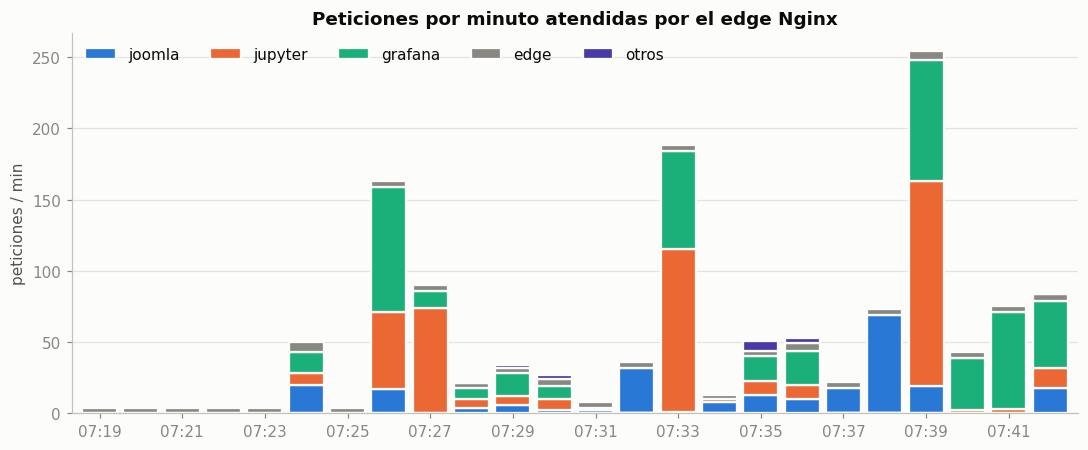

In [21]:
if edge.empty:
    print("Sin datos que graficar.")
else:
    por_minuto = (edge.assign(minuto=edge["time"].dt.floor("min"))
                      .pivot_table(index="minuto", columns="servicio",
                                   values="uri", aggfunc="count")
                      .fillna(0))
    orden = [s for s in ["joomla", "jupyter", "grafana", "edge", "otros"]
             if s in por_minuto.columns]
    por_minuto = por_minuto[orden]

    fig, ax = plt.subplots(figsize=(10, 4.2))
    por_minuto.plot(kind="bar", stacked=True, ax=ax, width=0.85,
                    color=[COLOR_SERVICIO[c] for c in por_minuto.columns],
                    edgecolor=SUPERFICIE, linewidth=1.5)

    ax.set_title("Peticiones por minuto atendidas por el edge Nginx")
    ax.set_xlabel("")
    ax.set_ylabel("peticiones / min")
    ax.grid(axis="y", linestyle="-", alpha=0.9)
    ax.set_axisbelow(True)

    etiquetas = [t.strftime("%H:%M") for t in por_minuto.index]
    paso = max(1, len(etiquetas) // 12)
    ax.set_xticks(range(0, len(etiquetas), paso))
    ax.set_xticklabels(etiquetas[::paso], rotation=0)

    ax.legend(title="", loc="upper left", ncols=len(orden))
    plt.tight_layout()
    plt.show()

### Grafica 2 - Respuestas por clase de codigo HTTP

Cada barra lleva su valor impreso, de modo que la lectura no depende del color:
2xx exito, 3xx redireccion, 4xx error del cliente, 5xx error del servidor.

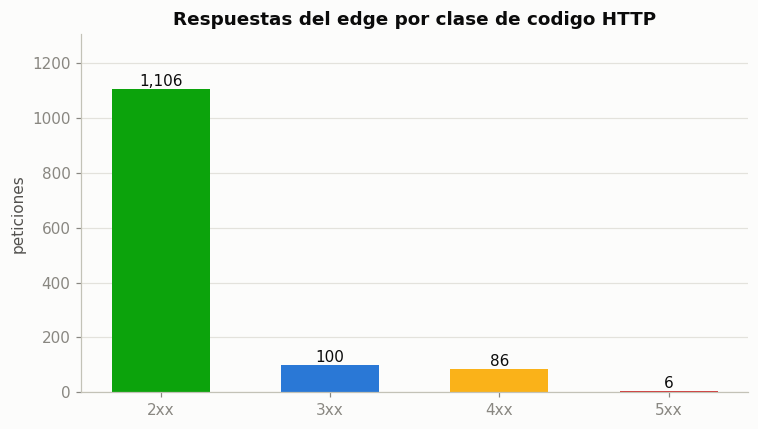

,clase_status,status,peticiones
1,2xx,200,1085
9,4xx,403,55
5,3xx,302,38
7,3xx,304,32
4,3xx,301,28
10,4xx,404,26
0,1xx,101,13
3,2xx,204,13
2,2xx,201,8
12,5xx,502,6


In [22]:
if edge.empty:
    print("Sin datos que graficar.")
else:
    clases = (edge["clase_status"].value_counts()
                                  .reindex(["2xx", "3xx", "4xx", "5xx"])
                                  .dropna())

    fig, ax = plt.subplots(figsize=(7, 4))
    barras = ax.bar(clases.index, clases.values, width=0.58,
                    color=[COLOR_STATUS[c] for c in clases.index])

    for barra, valor in zip(barras, clases.values):
        ax.text(barra.get_x() + barra.get_width() / 2, valor,
                f"{int(valor):,}", ha="center", va="bottom",
                fontsize=10, color=TINTA)

    ax.set_title("Respuestas del edge por clase de codigo HTTP")
    ax.set_ylabel("peticiones")
    ax.set_ylim(0, clases.max() * 1.18)
    ax.grid(axis="y", linestyle="-", alpha=0.9)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

    detalle = (edge.groupby(["clase_status", "status"])
                   .size().rename("peticiones").reset_index()
                   .sort_values("peticiones", ascending=False))
    display(detalle)

## 5. Procesado directo del archivo de log con pandas

Ademas de las vistas SQL, el cuaderno tiene montado el archivo crudo. Se lee
linea por linea tolerando registros truncados (el proceso de Nginx puede estar
escribiendo mientras se lee) y se calculan percentiles de latencia.

In [23]:
def leer_log_json(ruta, maximo=50000):
    """Lee un archivo JSON-lines descartando las lineas malformadas."""
    registros, descartadas = [], 0
    if not os.path.exists(ruta):
        print(f"Aun no existe {ruta}")
        return pd.DataFrame(), 0
    with open(ruta, "r", encoding="utf-8", errors="replace") as fh:
        for linea in fh:
            linea = linea.strip()
            if not linea:
                continue
            try:
                registros.append(json.loads(linea))
            except json.JSONDecodeError:
                descartadas += 1
    return pd.DataFrame(registros[-maximo:]), descartadas


crudo, descartadas = leer_log_json(LOG_EDGE)
print(f"Lineas validas: {len(crudo):,}   |   descartadas: {descartadas}")

if not crudo.empty:
    crudo["ts"] = pd.to_datetime(crudo["ts"], format="ISO8601", utc=True)
    percentiles = crudo["request_time"].quantile([0.50, 0.90, 0.95, 0.99])
    print("\nLatencia del edge (segundos):")
    for p, v in percentiles.items():
        print(f"  p{int(p*100):02d} = {v*1000:7.1f} ms")
    display(crudo.tail(5)[["ts", "remote_addr", "metodo", "uri",
                           "status", "request_time", "servicio"]])

Lineas validas: 1,314   |   descartadas: 0

Latencia del edge (segundos):
  p50 =     4.0 ms
  p90 =    61.0 ms
  p95 =    78.7 ms
  p99 =   506.2 ms


,ts,remote_addr,metodo,uri,status,request_time,servicio
1309,2026-09-20 07:42:19+00:00,172.28.10.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0.002,jupyter
1310,2026-09-20 07:42:20+00:00,172.28.10.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0.001,jupyter
1311,2026-09-20 07:42:20+00:00,172.28.10.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0.001,jupyter
1312,2026-09-20 07:42:20+00:00,172.28.10.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0.001,jupyter
1313,2026-09-20 07:42:20+00:00,172.28.10.1,GET,/jupyter/static/favicons/favicon-busy-1.ico,304,0.001,jupyter


### Grafica 3 - Percentiles de latencia del edge

Una barra horizontal por percentil, etiquetada con su valor: la forma correcta
para comparar unas pocas magnitudes con nombre.

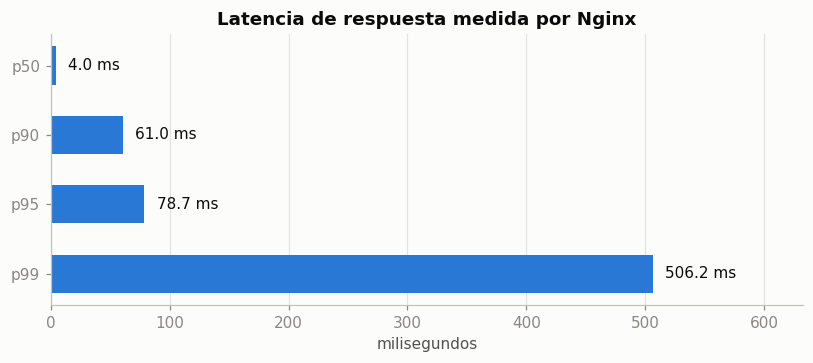

In [24]:
if crudo.empty:
    print("Sin datos que graficar.")
else:
    etiquetas = ["p50", "p90", "p95", "p99"]
    valores = [crudo["request_time"].quantile(q) * 1000 for q in (0.50, 0.90, 0.95, 0.99)]

    fig, ax = plt.subplots(figsize=(7.5, 3.4))
    barras = ax.barh(etiquetas, valores, height=0.55, color="#2a78d6")
    ax.invert_yaxis()

    for barra, valor in zip(barras, valores):
        ax.text(valor + max(valores) * 0.02, barra.get_y() + barra.get_height() / 2,
                f"{valor:.1f} ms", va="center", ha="left", fontsize=10, color=TINTA)

    ax.set_title("Latencia de respuesta medida por Nginx")
    ax.set_xlabel("milisegundos")
    ax.set_xlim(0, max(valores) * 1.25)
    ax.grid(axis="x", linestyle="-", alpha=0.9)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

### Log del CMS (Apache dentro del contenedor Joomla)

El mismo procedimiento aplicado al segundo volumen compartido. Observe que
`remote_addr` contiene la IP real del navegador -no la del proxy- porque
`mod_remoteip` promueve la cabecera `X-Forwarded-For` que inyecta Nginx.

In [25]:
cms, descartadas_cms = leer_log_json(LOG_JOOMLA)
print(f"Lineas validas: {len(cms):,}   |   descartadas: {descartadas_cms}")

if not cms.empty:
    columnas = [c for c in ["ts", "remote_addr", "proxy_addr", "metodo",
                            "uri", "status", "duracion_us"] if c in cms.columns]
    display(cms.tail(8)[columnas])
    print("\nIPs vistas por Apache (tras mod_remoteip):")
    display(cms["remote_addr"].value_counts().head())

Lineas validas: 331   |   descartadas: 0


,ts,remote_addr,proxy_addr,metodo,uri,status,duracion_us
323,2026-09-20T02:42:19-0500,172.28.10.3,172.28.10.5,GET,/templates/cassiopeia/images/logo.svg,404,36793
324,2026-09-20T02:42:19-0500,172.28.10.3,172.28.10.5,GET,/ruta-inexistente,404,36050
325,2026-09-20T02:42:19-0500,172.28.10.3,172.28.10.5,GET,/index.php,200,51346
326,2026-09-20T02:42:19-0500,172.28.10.3,172.28.10.5,GET,/index.php,200,51579
327,2026-09-20T02:42:19-0500,172.28.10.3,172.28.10.5,GET,/index.php,301,28503
328,2026-09-20T02:42:19-0500,172.28.10.3,172.28.10.5,GET,/administrator/index.php,200,42225
329,2026-09-20T02:42:19-0500,172.28.10.3,172.28.10.5,GET,/templates/cassiopeia/images/logo.svg,404,34170
330,2026-09-20T02:42:19-0500,172.28.10.3,172.28.10.5,GET,/ruta-inexistente,404,31893



IPs vistas por Apache (tras mod_remoteip):


remote_addr
172.28.10.1    185
127.0.0.1       92
172.28.10.3     54
Name: count, dtype: int64

## 6. Actividad interna del motor relacional

`pg_stat_database` expone contadores acumulados del servidor: conexiones
abiertas (sockets TCP vivos), transacciones confirmadas y eficacia de la cache.
Son las mismas cifras que muestran los paneles de Grafana.

In [26]:
actividad = pd.read_sql("SELECT * FROM observabilidad.actividad_bd", engine)
display(actividad.T.rename(columns={0: "valor"}))

,valor
time,2026-09-20 07:42:20.644850+00:00
base_datos,joomladb
conexiones_activas,1
transacciones_commit,12102
transacciones_rollback,12
bloques_disco,676
bloques_cache,807872
cache_hit_pct,99.92
tup_returned,694268
tup_fetched,482406


## 7. Conclusiones

* El cuaderno se conecta al motor **PostgreSQL** por nombre de servicio
  (`database`), resuelto por el DNS embebido de Docker en `127.0.0.11`, y
  atraviesa unicamente la red interna `backend_net`.
* El trafico generado contra `http://nginx` recorre la cadena completa
  **cliente -> edge -> backend**, deja rastro en dos access logs distintos y
  termina siendo consultable como SQL, tanto desde este cuaderno como desde los
  paneles de Grafana.
* Las tres graficas se construyeron sobre datos reales del despliegue: reparto
  de trafico por servicio, calidad de las respuestas por clase de codigo HTTP y
  latencia del proxy.
* Todo lo anterior se ejecuta sin instalar dependencias ni cargar el cuaderno a
  mano: el archivo llega por *bind-mount* y las librerias vienen en la imagen.